In [7]:
from proc import process_data
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
results = process_data()
results

successes=1,524,405,956
trials=4,012,000,000
(0.37994658495022327, 0.37997662359784834)
ConfidenceInterval(low=0.379946584950223, high=0.3799766235979915)
p=np.float64(0.3799616041874377)


,regular,seed,N
0,3851,1560148770,10000
1,3671,3222033341,10000
2,3880,4144223430,10000
3,3804,1402486079,10000
4,3862,1917096892,10000
...,...,...,...
95,3852,2523104598,10000
96,3835,1759880128,10000
97,3789,3789730212,10000
98,3836,4159484181,10000


In [14]:
results["cumulative_successes"] = np.cumsum(results["regular"])
results["cumulative_trials"]    = np.cumsum(results["N"])
results["p_hat_n"]              = results["cumulative_successes"] / results["cumulative_trials"]
alpha = 0.05
lower, upper = proportion_confint(results["cumulative_successes"], results["cumulative_trials"], alpha=alpha, method='beta')
results["lower"] = lower
results["upper"] = upper
results

,regular,seed,N,cumulative_successes,cumulative_trials,p_hat_n,lower,upper
0,3851,1560148770,10000,3851,10000,0.385100,0.375547,0.394720
1,3671,3222033341,10000,7522,20000,0.376100,0.369380,0.382856
2,3880,4144223430,10000,11402,30000,0.380067,0.374569,0.385587
3,3804,1402486079,10000,15206,40000,0.380150,0.375389,0.384928
4,3862,1917096892,10000,19068,50000,0.381360,0.377100,0.385634
...,...,...,...,...,...,...,...,...
95,3852,2523104598,10000,384507605,1011960000,0.379963,0.379933,0.379993
96,3835,1759880128,10000,384511440,1011970000,0.379963,0.379933,0.379993
97,3789,3789730212,10000,384515229,1011980000,0.379963,0.379933,0.379993
98,3836,4159484181,10000,384519065,1011990000,0.379963,0.379933,0.379993


C:\Users\fired\AppData\Local\Temp\ipykernel_36752\3321800368.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


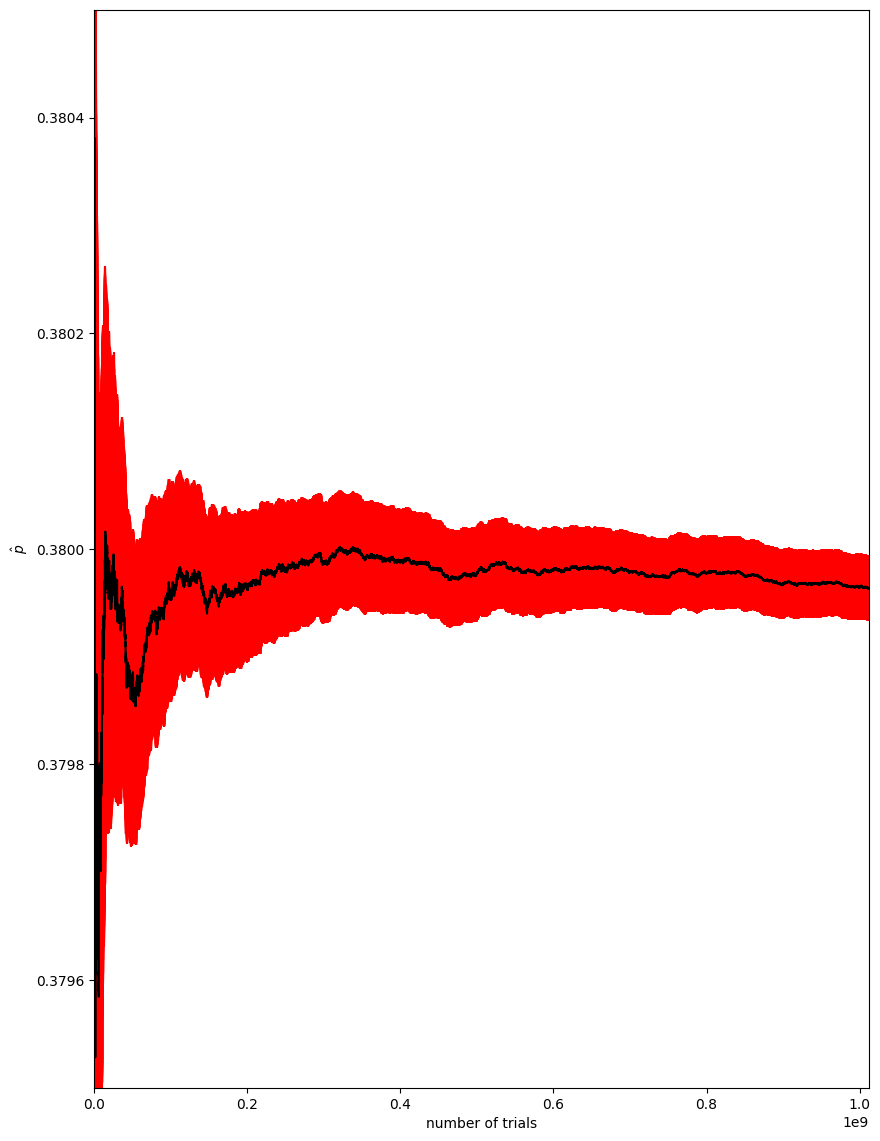

In [35]:
fig, ax = plt.subplots(figsize=(10, 14))
ax.errorbar(x=results["cumulative_trials"], y=results["p_hat_n"], yerr=(results["upper"]-results["lower"]) / 2, fmt='k-', ecolor='red')

ax.set_xlim(0, np.max(results["cumulative_trials"]))
ax.set_ylim(0.3795, 0.3805)
ax.set_xlabel("number of trials")
ax.set_ylabel(r"$\hat{p}$")
fig.show()